# Problem 3 — Audio entropy: ambient noise vs. music

**Group 6 — COMP4010 / MATH4010 Final Project**

## 3.a Data

We recorded **20 mono WAV clips of 5.12 s each, at 16 kHz / 16-bit PCM** and stored them in [`Data/q3/`](../../Data/q3/) under two subfolders:

| Class           | Files                                       | Description                                                |
|-----------------|---------------------------------------------|------------------------------------------------------------|
| Ambient noise   | `Data/q3/noise/noise_01.wav … noise_10.wav` | room noise / fan / AC / traffic / street rumble            |
| Music           | `Data/q3/music/music_01.wav … music_10.wav` | short melodies, chords and singing through a phone speaker |

**Recording setup.**

| Setting       | Value                                                |
|---------------|------------------------------------------------------|
| Device        | MacBook built-in microphone (laptop)                 |
| Channels      | 1 (mono)                                             |
| Bit depth     | 16-bit signed PCM                                    |
| Sample rate   | 16 000 Hz                                            |
| Clip length   | 5.12 s (81 920 samples each)                         |
| Container     | WAV (uncompressed)                                   |

> *Reproducing the data:* the WAV files are not committed to the repository. Run [`Data/q3/download_data.sh`](../../Data/q3/download_data.sh) (which uses `gdown` to pull the two Google Drive folders) to populate `Data/q3/music/` and `Data/q3/noise/` before executing the notebook.

## 3.b Compute four numbers per clip

Because the ambient-noise recordings are much quieter than the music recordings (sometimes by an order of magnitude in peak amplitude), we **peak-normalize each clip** to $\max_n |x_n| = 1$ before computing the entropy quantities. This puts every clip into the same dynamic range $[-1, 1]$, so a single bin width $\Delta$ resolves all 20 clips equally well (≈400 occupied bins each) and the histogram estimator is comparable across clips. The peak rescaling is a multiplicative constant, so it shifts $\widehat H$ and $H_{\text{Gauss}}$ by the same $\log_2$ amount and **leaves the gap $H_{\text{Gauss}} - \widehat H$ unchanged** (only the histogram estimator's bias is reduced).

For each (peak-normalized) clip $x_1,\dots,x_N \in [-1,1]$ we use a **common bin width $\Delta$** for all 20 clips and compute:

1. **Discrete (quantized) entropy.** Bin the samples with width $\Delta$ into $K$ bins, let $\widehat p_b = n_b/N$:
$$
\widehat H_Q \;=\; -\sum_{b} \widehat p_b \log_2 \widehat p_b \quad\text{(bits / sample)}.
$$
2. **Differential entropy estimate** (plug-in / histogram estimator):
$$
\widehat H \;=\; \widehat H_Q + \log_2 \Delta.
$$
3. **Discrete upper bound** (uniform over the $K$ occupied bins):
$$
H_{\max} \;=\; \log_2 K.
$$
4. **Gaussian reference** (max-entropy density for fixed variance $\widehat\sigma^2$):
$$
H_{\text{Gauss}} \;=\; \tfrac12 \log_2\!\bigl(2\pi e\, \widehat\sigma^2\bigr).
$$

The lecture predicts $\widehat H_Q \le H_{\max}$ and $\widehat H \le H_{\text{Gauss}}$ (max-entropy-given-variance), with equality iff the sample distribution is uniform / Gaussian respectively.

In [17]:
import os
import glob
import wave
from statistics import NormalDist

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = os.path.abspath(os.path.join("..", "..", "Data", "q3"))
assert os.path.isdir(DATA_DIR), f"Data dir not found: {DATA_DIR}"
print("Reading WAV files from:", DATA_DIR)

DELTA = 0.005          # common bin width for all 20 clips (normalized [-1, 1] units)
TARGET_SR = 16000      # expected sampling rate
RNG = np.random.default_rng(4010)


Reading WAV files from: /Users/dinhieufam/DINHHIEU/VINUNI/Spring 26/MATH4010 - Advanced Probility and Statistics/COMP4010--Advanced-Prob-Stat----Final-Project/Data/q3


In [18]:
def load_wav_mono(path):
    """Load a mono 16-bit PCM WAV file as float64 in [-1, 1)."""
    with wave.open(path, "rb") as w:
        sr = w.getframerate()
        nch = w.getnchannels()
        sw = w.getsampwidth()
        nframes = w.getnframes()
        raw = w.readframes(nframes)
    assert sw == 2, f"{path}: expected 16-bit PCM, got sample width {sw}"
    x = np.frombuffer(raw, dtype=np.int16).astype(np.float64)
    if nch > 1:                              # downmix to mono if needed
        x = x.reshape(-1, nch).mean(axis=1)
    return sr, x / 32768.0


def peak_normalize(x):
    """Scale one clip to max |x| = 1, preserving silence if present."""
    peak = float(np.max(np.abs(x)))
    return x if peak == 0 else x / peak


def entropy_quantities(x, delta):
    """Return (H_Q, H_diff, H_max, H_gauss, K, sigma2) in bits using bin width `delta`."""
    lo, hi = float(np.min(x)), float(np.max(x))
    K = max(2, int(np.ceil((hi - lo) / delta)))
    edges = lo + delta * np.arange(K + 1)
    edges[-1] = max(edges[-1], hi + np.finfo(float).eps)
    counts, _ = np.histogram(x, bins=edges)
    p = counts.astype(np.float64) / counts.sum()
    nz = p > 0
    H_Q     = float(-np.sum(p[nz] * np.log2(p[nz])))
    H_diff  = float(H_Q + np.log2(delta))
    H_max   = float(np.log2(K))
    sigma2  = float(np.var(x))
    H_gauss = float(0.5 * np.log2(2 * np.pi * np.e * sigma2)) if sigma2 > 0 else -np.inf
    return H_Q, H_diff, H_max, H_gauss, K, sigma2


def load_clip(cls, fname, normalized=True):
    """Load a clip by class/file name and optionally apply the analysis normalization."""
    sr, x = load_wav_mono(os.path.join(DATA_DIR, cls, fname))
    assert sr == TARGET_SR, f"{fname}: sample rate {sr} != {TARGET_SR}"
    return peak_normalize(x) if normalized else x


def clip_path(cls, fname):
    return os.path.join(DATA_DIR, cls, fname)


In [19]:
rows = []
class_dirs = {"noise": os.path.join(DATA_DIR, "noise"),
              "music": os.path.join(DATA_DIR, "music")}
for cls, cdir in class_dirs.items():
    assert os.path.isdir(cdir), f"Missing class folder: {cdir}"
    for path in sorted(glob.glob(os.path.join(cdir, "*.wav"))):
        fname = os.path.basename(path)
        sr, raw = load_wav_mono(path)
        assert sr == TARGET_SR, f"{fname}: sample rate {sr} != {TARGET_SR}"
        peak = float(np.max(np.abs(raw)))
        x = peak_normalize(raw)
        H_Q, H_diff, H_max, H_gauss, K, sigma2 = entropy_quantities(x, DELTA)
        rows.append({
            "file":     fname,
            "class":    cls,
            "N":        len(x),
            "peak":     peak,
            "sigma2":   sigma2,
            "K_bins":   K,
            "H_Q":      H_Q,
            "H_diff":   H_diff,
            "H_max":    H_max,
            "H_gauss":  H_gauss,
            "gap":      H_gauss - H_diff,
        })
df = pd.DataFrame(rows).sort_values(["class", "file"]).reset_index(drop=True)
df.round(4)


,file,class,N,peak,sigma2,K_bins,H_Q,H_diff,H_max,H_gauss,gap
0,music_01.wav,music,80000,0.9004,0.0563,388,7.5378,-0.1060,8.5999,-0.0289,0.0772
1,music_02.wav,music,80000,0.1931,0.0165,362,6.3891,-1.2548,8.4998,-0.9121,0.3427
2,music_03.wav,music,80000,0.7605,0.0192,363,6.7124,-0.9315,8.5038,-0.8036,0.1279
3,music_04.wav,music,80000,0.6136,0.0580,392,7.2203,-0.4235,8.6147,-0.0062,0.4173
4,music_05.wav,music,80000,0.6657,0.0284,382,7.0666,-0.5773,8.5774,-0.5217,0.0556
5,music_06.wav,music,80000,0.9804,0.0156,396,6.5114,-1.1325,8.6294,-0.9552,0.1772
6,music_07.wav,music,80000,0.3149,0.0440,384,7.4177,-0.2262,8.5850,-0.2062,0.0200
7,music_08.wav,music,80000,1.0000,0.0568,394,7.5924,-0.0515,8.6221,-0.0225,0.0290
8,music_09.wav,music,80000,0.7105,0.0535,397,7.5046,-0.1393,8.6330,-0.0657,0.0736
9,music_10.wav,music,80000,0.8743,0.0221,388,6.8528,-0.7911,8.5999,-0.7037,0.0874


## 3.c Discussion — class summaries

We report the **mean ± std** of each quantity within each class, and the per-clip gap $H_{\text{Gauss}} - \widehat H$ between the Gaussian reference and the histogram estimate.

In [20]:
summary = (
    df.groupby("class")[["H_Q", "H_diff", "H_max", "H_gauss", "gap", "sigma2"]]
      .agg(["mean", "std"])
      .round(4)
)
summary

H_Q          H_diff           H_max         H_gauss             gap  \
         mean     std    mean     std    mean     std    mean     std    mean   
class                                                                           
music  7.0805  0.4439 -0.5634  0.4439  8.5865  0.0481 -0.4226  0.3972  0.1408   
noise  6.1606  1.2001 -1.4832  1.2001  8.5059  0.1225 -1.1531  1.0073  0.3301   

               sigma2          
          std    mean     std  
class                          
music  0.1352  0.0370  0.0183  
noise  0.3238  0.0348  0.0667

In [21]:
# Compact one-line-per-class summary for the writeup
for cls, g in df.groupby("class"):
    print(f"--- {cls.upper()} (n={len(g)}) ---")
    for col in ["H_Q", "H_diff", "H_max", "H_gauss", "gap"]:
        m, s = g[col].mean(), g[col].std()
        print(f"  {col:>8s}:  mean = {m:+.4f}   std = {s:.4f}")
    print()

--- MUSIC (n=10) ---
       H_Q:  mean = +7.0805   std = 0.4439
    H_diff:  mean = -0.5634   std = 0.4439
     H_max:  mean = +8.5865   std = 0.0481
   H_gauss:  mean = -0.4226   std = 0.3972
       gap:  mean = +0.1408   std = 0.1352

--- NOISE (n=10) ---
       H_Q:  mean = +6.1606   std = 1.2001
    H_diff:  mean = -1.4832   std = 1.2001
     H_max:  mean = +8.5059   std = 0.1225
   H_gauss:  mean = -1.1531   std = 1.0073
       gap:  mean = +0.3301   std = 0.3238



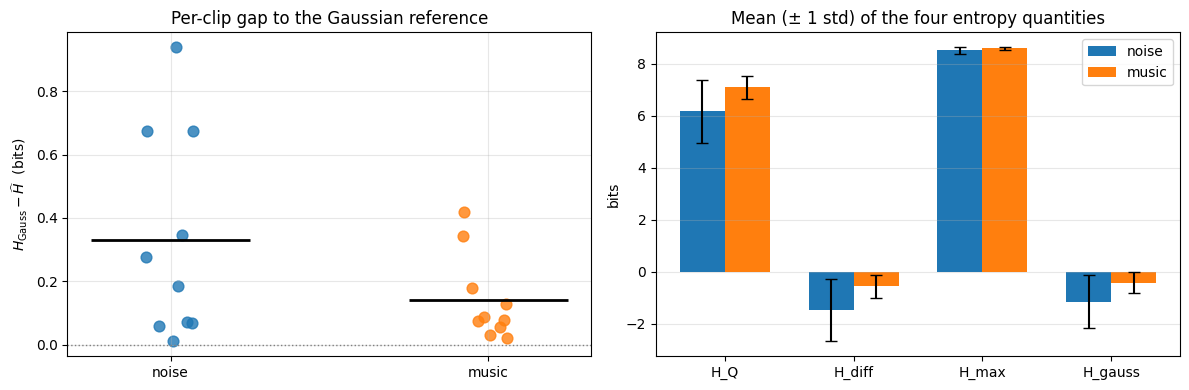

In [22]:
# Visual comparison: per-clip gap (left), and the four entropies as grouped bars (right)
rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for i, cls in enumerate(["noise", "music"]):
    g = df.loc[df["class"] == cls, "gap"].values
    jitter = rng.uniform(-0.08, 0.08, size=g.size)
    ax.scatter(np.full_like(g, i, dtype=float) + jitter, g, s=60, alpha=0.8, label=cls)
    ax.hlines(g.mean(), i - 0.25, i + 0.25, colors="k", linewidth=2)
ax.set_xticks([0, 1]); ax.set_xticklabels(["noise", "music"])
ax.set_ylabel(r"$H_{\mathrm{Gauss}} - \widehat H$  (bits)")
ax.set_title("Per-clip gap to the Gaussian reference")
ax.axhline(0, color="gray", linestyle=":", linewidth=1)
ax.grid(True, alpha=0.3)

ax = axes[1]
metrics = ["H_Q", "H_diff", "H_max", "H_gauss"]
x = np.arange(len(metrics)); width = 0.35
for j, cls in enumerate(["noise", "music"]):
    g = df[df["class"] == cls]
    means = [g[m].mean() for m in metrics]
    stds  = [g[m].std()  for m in metrics]
    ax.bar(x + (j - 0.5) * width, means, width, yerr=stds, capsize=4, label=cls)
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylabel("bits")
ax.set_title("Mean (\u00b1 1 std) of the four entropy quantities")
ax.legend(); ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout(); plt.show()

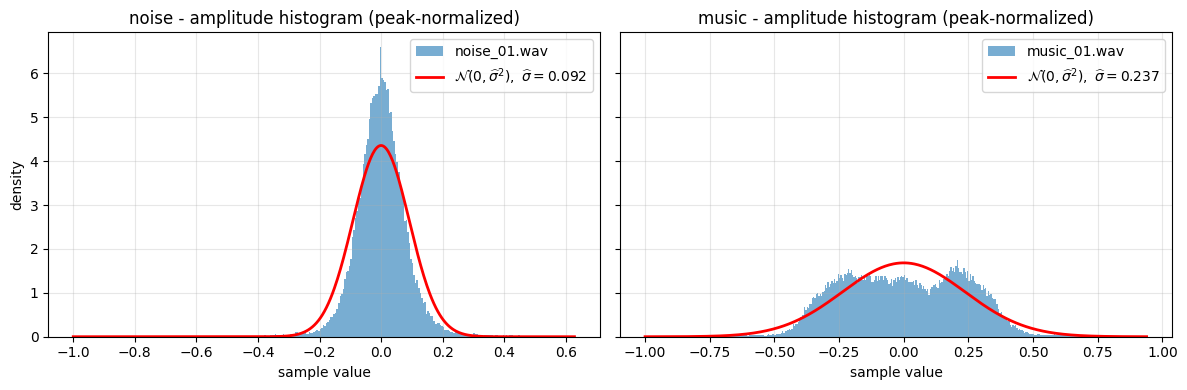

In [23]:
# Sample-amplitude histograms (one representative clip per class) with the
# matched-variance Gaussian overlaid -- visualizes why the gap differs.
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, cls in zip(axes, ["noise", "music"]):
    fname = df.loc[df["class"] == cls, "file"].iloc[0]
    _, x = load_wav_mono(os.path.join(DATA_DIR, cls, fname))
    x = x / np.max(np.abs(x))                # match the analysis pipeline
    sig = x.std()
    ax.hist(x, bins=np.arange(x.min(), x.max() + DELTA, DELTA),
            density=True, alpha=0.6, label=f"{fname}")
    xs = np.linspace(x.min(), x.max(), 500)
    gauss = np.exp(-xs ** 2 / (2 * sig ** 2)) / (sig * np.sqrt(2 * np.pi))
    ax.plot(xs, gauss, "r-", linewidth=2,
            label=fr"$\mathcal{{N}}(0,\widehat\sigma^2),\ \widehat\sigma={sig:.3f}$")
    ax.set_title(f"{cls} - amplitude histogram (peak-normalized)")
    ax.set_xlabel("sample value"); ax.legend()
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("density")
plt.tight_layout(); plt.show()

In [24]:
# Numerical comparison of typical gaps
noise_gap = df.loc[df["class"] == "noise", "gap"]
music_gap = df.loc[df["class"] == "music", "gap"]
print(f"H_Gauss - H_hat  (noise):   mean = {noise_gap.mean():.4f}   median = {noise_gap.median():.4f}   std = {noise_gap.std():.4f}")
print(f"H_Gauss - H_hat  (music):   mean = {music_gap.mean():.4f}   median = {music_gap.median():.4f}   std = {music_gap.std():.4f}")
print(f"\nRatio of means (music / noise) = {music_gap.mean() / max(noise_gap.mean(), 1e-9):.2f}x")

H_Gauss - H_hat  (noise):   mean = 0.3301   median = 0.2295   std = 0.3238
H_Gauss - H_hat  (music):   mean = 0.1408   median = 0.0823   std = 0.1352

Ratio of means (music / noise) = 0.43x


## 3.d Extra exploration from the improvement plan

The five added checks below address the main weaknesses of a single whole-clip histogram estimate: bin-width dependence, temporal averaging, visual Gaussian fit, small-sample uncertainty, and frequency-domain structure.


### 1. Bin-width sensitivity analysis

Histogram entropy estimates depend on the bin width $\Delta$. To check whether the class conclusion is an artifact of $\Delta=0.005$, we recompute $\widehat H_Q$, $\widehat H$, $H_{\max}$, $H_{\text{Gauss}}$, and the gap for $\Delta \in \{2^{-15},\dots,2^{-8}\}$ on the same peak-normalized clips.


In [25]:
deltas = np.array([2.0 ** (-k) for k in range(15, 7, -1)])
sensitivity_rows = []
for delta in deltas:
    for _, row in df.iterrows():
        x = load_clip(row["class"], row["file"], normalized=True)
        H_Q, H_diff, H_max, H_gauss, K, sigma2 = entropy_quantities(x, delta)
        sensitivity_rows.append({
            "delta": delta,
            "file": row["file"],
            "class": row["class"],
            "H_Q": H_Q,
            "H_diff": H_diff,
            "H_max": H_max,
            "H_gauss": H_gauss,
            "gap": H_gauss - H_diff,
            "K_bins": K,
        })

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_summary = (
    sensitivity_df.groupby(["delta", "class"])[["H_Q", "H_diff", "H_max", "H_gauss", "gap", "K_bins"]]
    .agg(["mean", "std"])
    .round(4)
)
sensitivity_summary


H_Q          H_diff            H_max         H_gauss  \
                   mean     std    mean     std     mean     std    mean   
delta    class                                                             
0.000031 music  13.5043  0.9044 -1.4957  0.9044  15.9408  0.0486 -0.4226   
         noise  11.2659  1.1898 -3.7341  1.1898  15.8599  0.1223 -1.1531   
0.000061 music  12.9991  0.6939 -1.0009  0.6939  14.9408  0.0486 -0.4226   
         noise  11.2185  1.1675 -2.7815  1.1675  14.8599  0.1223 -1.1531   
0.000122 music  12.2671  0.4947 -0.7329  0.4947  13.9408  0.0486 -0.4226   
         noise  10.8605  1.1682 -2.1395  1.1682  13.8599  0.1223 -1.1531   
0.000244 music  11.3597  0.4511 -0.6403  0.4511  12.9409  0.0486 -0.4226   
         noise  10.1719  1.0830 -1.8281  1.0830  12.8600  0.1223 -1.1531   
0.000488 music  10.4008  0.4443 -0.5992  0.4443  11.9409  0.0486 -0.4226   
         noise   9.3391  1.0833 -1.6609  1.0833  11.8601  0.1223 -1.1531   
0.000977 music   9.4188  0.4449 -0.5812  0.4449  10.9411  0.0485 -0.4226   
         noise   8.4619  1.1519 -1.5381  1.1519  10.8604  0.1222 -1.1531   
0.001953 music   8.4288  0.4447 -0.5712  0.4447   9.9414  0.0483 -0.4226   
         noise   7.5023  1.1899 -1.4977  1.1899   9.8607  0.1223 -1.1531   
0.003906 music   7.4350  0.4441 -0.5650  0.4441   8.9421  0.0482 -0.4226   
         noise   6.5153  1.2004 -1.4847  1.2004   8.8611  0.1226 -1.1531   

                           gap           K_bins             
                   std    mean     std     mean        std  
delta    class                                              
0.000031 music  0.3972  1.0731  0.7504  62931.1  2087.5992  
         noise  1.0073  2.5809  1.2032  59661.1  4972.2214  
0.000061 music  0.3972  0.5783  0.4695  31465.8  1043.7832  
         noise  1.0073  1.6284  1.1444  29830.9  2486.0535  
0.000122 music  0.3972  0.3103  0.2094  15733.2   521.8861  
         noise  1.0073  0.9864  0.9304  14915.8  1243.0900  
0.000244 music  0.3972  0.2177  0.1447   7867.0   260.8784  
         noise  1.0073  0.6749  0.6675   7458.3   621.4524  
0.000488 music  0.3972  0.1766  0.1348   3933.7   130.5493  
         noise  1.0073  0.5078  0.4337   3729.4   310.8237  
0.000977 music  0.3972  0.1586  0.1349   1967.1    65.1621  
         noise  1.0073  0.3849  0.3037   1865.0   155.3512  
0.001953 music  0.3972  0.1487  0.1352    983.7    32.4210  
         noise  1.0073  0.3446  0.3169    932.7    77.7218  
0.003906 music  0.3972  0.1424  0.1353    492.1    16.1689  
         noise  1.0073  0.3316  0.3242    466.5    38.9850

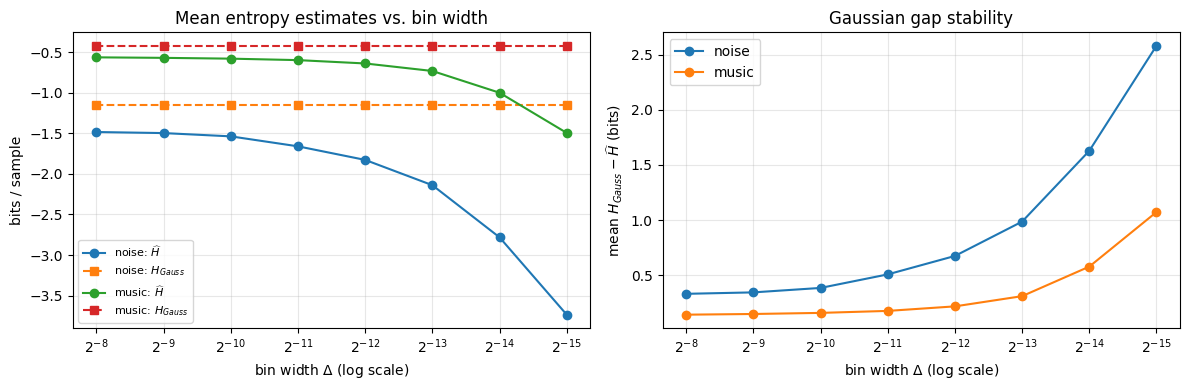

class,music,noise,noise_minus_music
delta,,,
0.000031,1.0731,2.5809,1.5078
0.000061,0.5783,1.6284,1.0501
0.000122,0.3103,0.9864,0.6760
0.000244,0.2177,0.6749,0.4572
0.000488,0.1766,0.5078,0.3312
0.000977,0.1586,0.3849,0.2264
0.001953,0.1487,0.3446,0.1959
0.003906,0.1424,0.3316,0.1892


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for cls in ["noise", "music"]:
    g = sensitivity_df[sensitivity_df["class"] == cls]
    mean_by_delta = g.groupby("delta")[["H_diff", "H_gauss", "gap"]].mean()
    axes[0].plot(mean_by_delta.index, mean_by_delta["H_diff"], marker="o", label=fr"{cls}: $\widehat H$")
    axes[0].plot(mean_by_delta.index, mean_by_delta["H_gauss"], marker="s", linestyle="--", label=fr"{cls}: $H_{{Gauss}}$")
    axes[1].plot(mean_by_delta.index, mean_by_delta["gap"], marker="o", label=cls)

for ax in axes:
    ax.set_xscale("log", base=2)
    ax.invert_xaxis()
    ax.grid(True, alpha=0.3)
    ax.set_xlabel(r"bin width $\Delta$ (log scale)")
axes[0].set_ylabel("bits / sample")
axes[0].set_title("Mean entropy estimates vs. bin width")
axes[1].set_ylabel(r"mean $H_{Gauss} - \widehat H$ (bits)")
axes[1].set_title("Gaussian gap stability")
axes[0].legend(fontsize=8)
axes[1].legend()
plt.tight_layout(); plt.show()

pivot_gap = sensitivity_df.pivot_table(index="delta", columns="class", values="gap", aggfunc="mean")
pivot_gap["noise_minus_music"] = pivot_gap["noise"] - pivot_gap["music"]
pivot_gap.round(4)


### 2. Frame-level entropy analysis

Whole-clip entropy hides temporal structure. We split each 5.12 s recording into 50 ms frames with a 25 ms hop, compute entropy per frame, and summarize the frame mean/std for each clip.


In [27]:
FRAME_MS = 50
HOP_MS = 25
frame_len = int(TARGET_SR * FRAME_MS / 1000)
hop_len = int(TARGET_SR * HOP_MS / 1000)


def frame_entropy_table(x, delta=DELTA):
    rows = []
    for start in range(0, len(x) - frame_len + 1, hop_len):
        frame = x[start:start + frame_len]
        H_Q, H_diff, H_max, H_gauss, K, sigma2 = entropy_quantities(frame, delta)
        rows.append({
            "time_s": start / TARGET_SR,
            "H_Q": H_Q,
            "H_diff": H_diff,
            "H_max": H_max,
            "H_gauss": H_gauss,
            "gap": H_gauss - H_diff,
            "sigma2": sigma2,
            "K_bins": K,
        })
    return pd.DataFrame(rows)

frame_rows = []
for _, row in df.iterrows():
    x = load_clip(row["class"], row["file"], normalized=True)
    ftab = frame_entropy_table(x)
    frame_rows.append({
        "file": row["file"],
        "class": row["class"],
        "n_frames": len(ftab),
        "frame_H_mean": ftab["H_diff"].mean(),
        "frame_H_std": ftab["H_diff"].std(),
        "frame_gap_mean": ftab["gap"].mean(),
        "frame_gap_std": ftab["gap"].std(),
    })

frame_df = pd.DataFrame(frame_rows)
frame_summary = frame_df.groupby("class")[["frame_H_mean", "frame_H_std", "frame_gap_mean", "frame_gap_std"]].agg(["mean", "std"]).round(4)
frame_summary


frame_H_mean         frame_H_std         frame_gap_mean          \
              mean     std        mean     std           mean     std   
class                                                                   
music      -1.1631  0.5688      0.9037  0.4210         0.2638  0.1011   
noise      -1.8893  1.2090      0.6098  0.2548         0.2405  0.1894   

      frame_gap_std          
               mean     std  
class                        
music        0.1991  0.1444  
noise        0.1885  0.0421

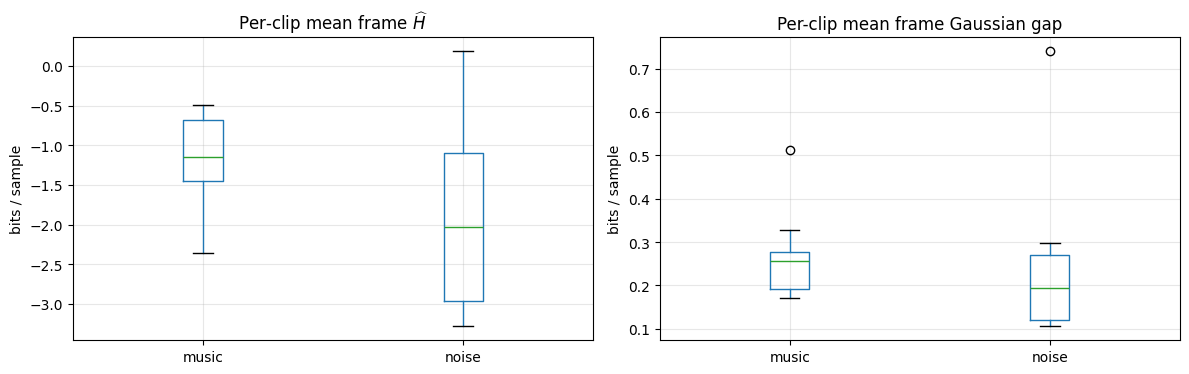

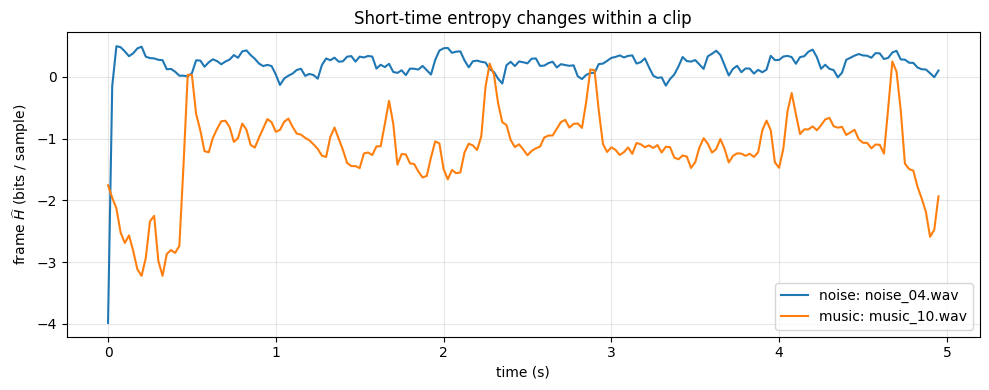

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
frame_df.boxplot(column="frame_H_mean", by="class", ax=axes[0])
frame_df.boxplot(column="frame_gap_mean", by="class", ax=axes[1])
axes[0].set_title(r"Per-clip mean frame $\widehat H$")
axes[1].set_title(r"Per-clip mean frame Gaussian gap")
for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("bits / sample")
    ax.grid(True, alpha=0.3)
fig.suptitle("")
plt.tight_layout(); plt.show()

# Show the temporal entropy trace for one representative clip from each class.
fig, ax = plt.subplots(figsize=(10, 4))
for cls in ["noise", "music"]:
    fname = df.loc[df["class"] == cls].sort_values("gap").iloc[len(df[df["class"] == cls]) // 2]["file"]
    trace = frame_entropy_table(load_clip(cls, fname, normalized=True))
    ax.plot(trace["time_s"], trace["H_diff"], label=f"{cls}: {fname}")
ax.set_xlabel("time (s)")
ax.set_ylabel(r"frame $\widehat H$ (bits / sample)")
ax.set_title("Short-time entropy changes within a clip")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout(); plt.show()


### 3. Amplitude distributions vs. Gaussian references

For each class, we show two representative clips: the median-gap clip and the largest-gap clip. The histogram compares the empirical amplitude density with the matched-variance Gaussian; the Q-Q plot shows tail/shape departures from Gaussianity.


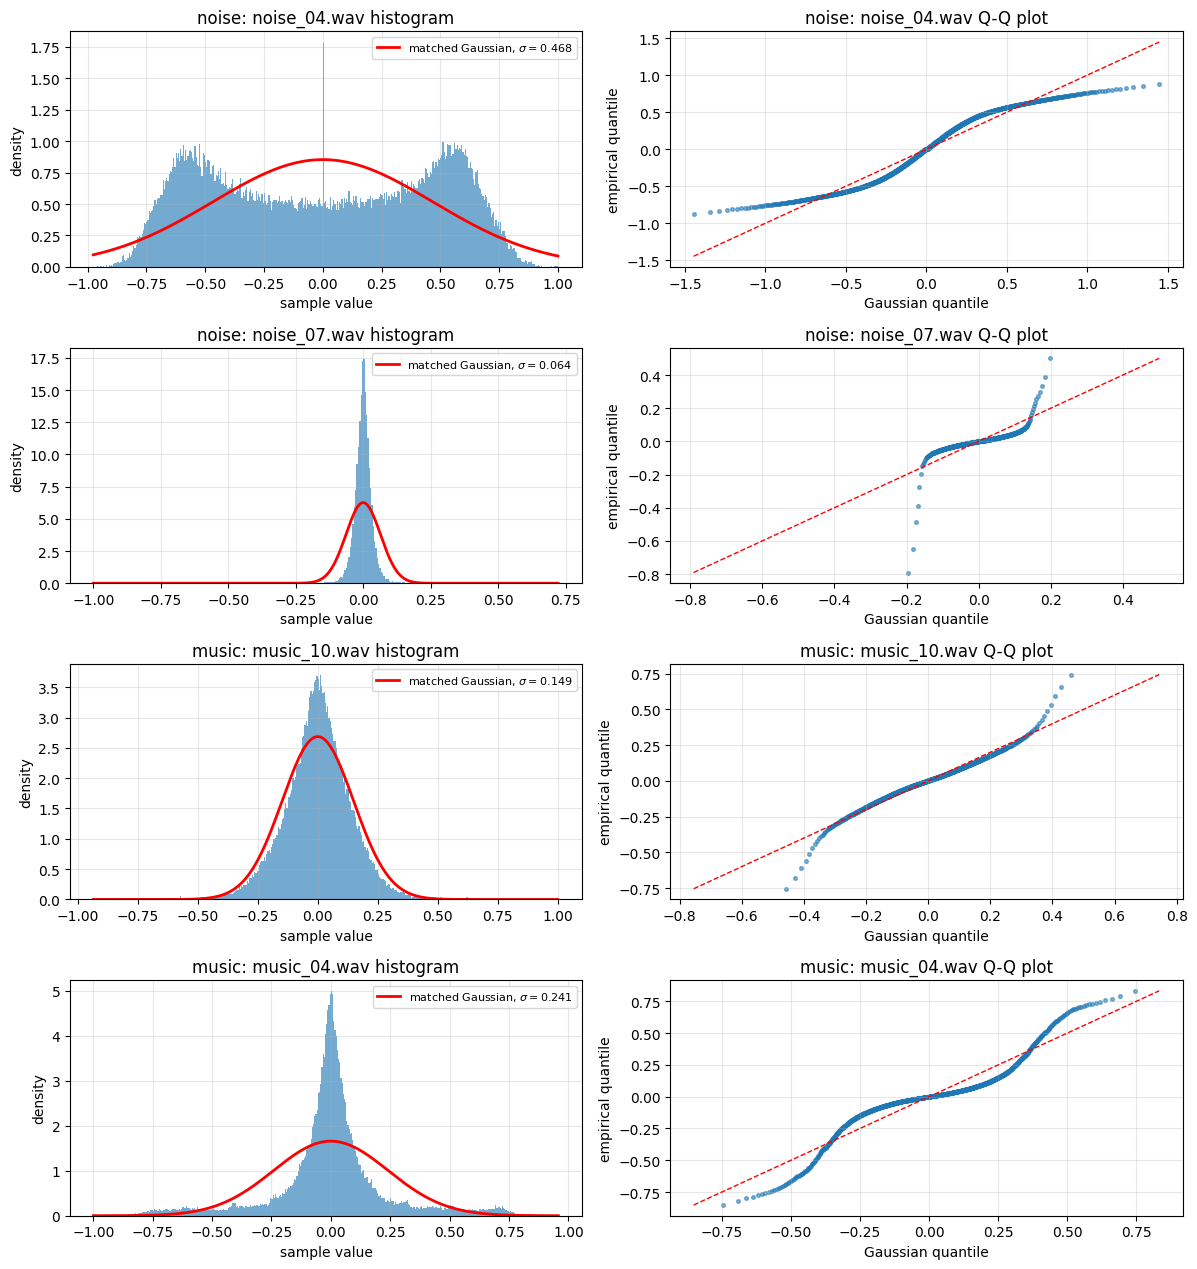

In [29]:
def representative_files_for_class(cls):
    g = df[df["class"] == cls].sort_values("gap").reset_index(drop=True)
    return [g.iloc[len(g) // 2]["file"], g.iloc[-1]["file"]]

normal = NormalDist()
qq_probs = np.linspace(0.001, 0.999, 999)
representatives = [(cls, fname) for cls in ["noise", "music"] for fname in representative_files_for_class(cls)]
fig, axes = plt.subplots(len(representatives), 2, figsize=(12, 3.2 * len(representatives)))

for row_ax, (cls, fname) in zip(axes, representatives):
    x = load_clip(cls, fname, normalized=True)
    mu = float(np.mean(x))
    sig = float(np.std(x))
    xs = np.linspace(x.min(), x.max(), 600)
    gauss = np.exp(-0.5 * ((xs - mu) / sig) ** 2) / (sig * np.sqrt(2 * np.pi))

    hist_ax, qq_ax = row_ax
    hist_ax.hist(x, bins=np.arange(x.min(), x.max() + DELTA, DELTA), density=True, alpha=0.62)
    hist_ax.plot(xs, gauss, "r-", linewidth=2, label=fr"matched Gaussian, $\sigma={sig:.3f}$")
    hist_ax.set_title(f"{cls}: {fname} histogram")
    hist_ax.set_xlabel("sample value")
    hist_ax.set_ylabel("density")
    hist_ax.grid(True, alpha=0.3)
    hist_ax.legend(fontsize=8)

    theoretical = mu + sig * np.array([normal.inv_cdf(float(p)) for p in qq_probs])
    empirical = np.quantile(x, qq_probs)
    lim = [min(theoretical.min(), empirical.min()), max(theoretical.max(), empirical.max())]
    qq_ax.scatter(theoretical, empirical, s=7, alpha=0.55)
    qq_ax.plot(lim, lim, "r--", linewidth=1)
    qq_ax.set_title(f"{cls}: {fname} Q-Q plot")
    qq_ax.set_xlabel("Gaussian quantile")
    qq_ax.set_ylabel("empirical quantile")
    qq_ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


### 4. Bootstrap confidence intervals and effect size

With only 10 clips per class, mean/std alone is fragile. We bootstrap clips within class to estimate 95% confidence intervals for the class mean gap and the difference in means, and we report Cohen's $d$ for the gap separation.


In [30]:
def bootstrap_ci(values, statistic=np.mean, n_boot=10000, confidence=0.95, rng=RNG):
    values = np.asarray(values, dtype=float)
    stats = np.empty(n_boot)
    for b in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        stats[b] = statistic(sample)
    alpha = (1 - confidence) / 2
    return float(np.quantile(stats, alpha)), float(np.quantile(stats, 1 - alpha))

bootstrap_rows = []
for cls in ["noise", "music"]:
    values = df.loc[df["class"] == cls, "gap"].to_numpy()
    lo, hi = bootstrap_ci(values)
    bootstrap_rows.append({
        "quantity": f"mean gap ({cls})",
        "estimate": values.mean(),
        "ci_95_low": lo,
        "ci_95_high": hi,
    })

noise_values = df.loc[df["class"] == "noise", "gap"].to_numpy()
music_values = df.loc[df["class"] == "music", "gap"].to_numpy()

def diff_mean_stat(sampled_pairs):
    n = len(noise_values)
    return sampled_pairs[:n].mean() - sampled_pairs[n:].mean()

# Bootstrap each class independently for the noise-minus-music mean gap.
diff_stats = np.empty(10000)
for b in range(len(diff_stats)):
    n_sample = RNG.choice(noise_values, size=len(noise_values), replace=True)
    m_sample = RNG.choice(music_values, size=len(music_values), replace=True)
    diff_stats[b] = n_sample.mean() - m_sample.mean()

pooled_sd = np.sqrt(((len(noise_values) - 1) * noise_values.var(ddof=1) +
                     (len(music_values) - 1) * music_values.var(ddof=1)) /
                    (len(noise_values) + len(music_values) - 2))
cohens_d = (noise_values.mean() - music_values.mean()) / pooled_sd
bootstrap_rows.append({
    "quantity": "mean gap difference (noise - music)",
    "estimate": noise_values.mean() - music_values.mean(),
    "ci_95_low": float(np.quantile(diff_stats, 0.025)),
    "ci_95_high": float(np.quantile(diff_stats, 0.975)),
})
bootstrap_rows.append({
    "quantity": "Cohen's d for gap (noise vs music)",
    "estimate": cohens_d,
    "ci_95_low": np.nan,
    "ci_95_high": np.nan,
})

bootstrap_df = pd.DataFrame(bootstrap_rows)
bootstrap_df.round(4)


,quantity,estimate,ci_95_low,ci_95_high
0,mean gap (noise),0.3301,0.1518,0.5254
1,mean gap (music),0.1408,0.0689,0.2251
2,mean gap difference (noise - music),0.1893,-0.0067,0.4057
3,Cohen's d for gap (noise vs music),0.7629,NaN,NaN


### 5. Spectral entropy as an audio-specific check

Time-domain amplitude entropy ignores frequency organization. Spectral entropy treats the normalized power spectrum as a probability distribution; higher values indicate power spread broadly across frequencies, while lower values indicate concentration in fewer frequency bands.


In [31]:
def spectral_entropy(x, sr=TARGET_SR, frame_ms=50, hop_ms=25):
    frame_len = int(sr * frame_ms / 1000)
    hop_len = int(sr * hop_ms / 1000)
    window = np.hanning(frame_len)
    values = []
    for start in range(0, len(x) - frame_len + 1, hop_len):
        frame = x[start:start + frame_len] * window
        power = np.abs(np.fft.rfft(frame)) ** 2
        total = power.sum()
        if total <= 0:
            continue
        p = power / total
        nz = p > 0
        H = -np.sum(p[nz] * np.log2(p[nz]))
        H_norm = H / np.log2(len(p))
        values.append(H_norm)
    return np.asarray(values)

spectral_rows = []
for _, row in df.iterrows():
    x = load_clip(row["class"], row["file"], normalized=True)
    s = spectral_entropy(x)
    spectral_rows.append({
        "file": row["file"],
        "class": row["class"],
        "spectral_entropy_mean": s.mean(),
        "spectral_entropy_std": s.std(ddof=1),
    })

spectral_df = pd.DataFrame(spectral_rows)
spectral_summary = spectral_df.groupby("class")[["spectral_entropy_mean", "spectral_entropy_std"]].agg(["mean", "std"]).round(4)
spectral_summary


spectral_entropy_mean         spectral_entropy_std        
                       mean     std                 mean     std
class                                                           
music                0.4090  0.0854               0.0997  0.0319
noise                0.4642  0.1619               0.0888  0.0450

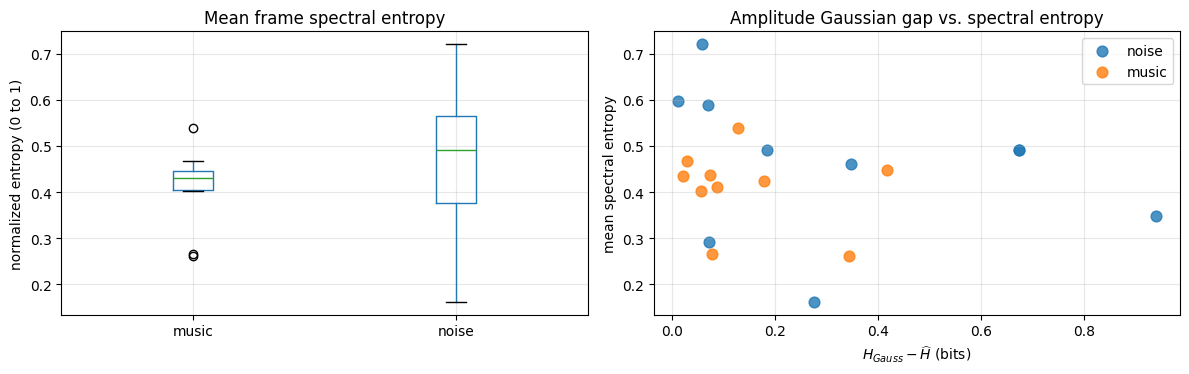

,file,class,gap,spectral_entropy_mean,spectral_entropy_std
0,music_01.wav,music,0.0772,0.2657,0.0863
1,music_02.wav,music,0.3427,0.2618,0.0944
2,music_03.wav,music,0.1279,0.5390,0.0912
3,music_04.wav,music,0.4173,0.4488,0.1838
4,music_05.wav,music,0.0556,0.4026,0.1144
5,music_06.wav,music,0.1772,0.4235,0.0888
6,music_07.wav,music,0.0200,0.4354,0.0928
7,music_08.wav,music,0.0290,0.4665,0.0988
8,music_09.wav,music,0.0736,0.4359,0.0712
9,music_10.wav,music,0.0874,0.4103,0.0751


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
spectral_df.boxplot(column="spectral_entropy_mean", by="class", ax=axes[0])
merged_features = df[["file", "class", "gap"]].merge(spectral_df, on=["file", "class"])
for cls in ["noise", "music"]:
    g = merged_features[merged_features["class"] == cls]
    axes[1].scatter(g["gap"], g["spectral_entropy_mean"], s=60, alpha=0.8, label=cls)
axes[0].set_title("Mean frame spectral entropy")
axes[0].set_xlabel("")
axes[0].set_ylabel("normalized entropy (0 to 1)")
axes[1].set_title("Amplitude Gaussian gap vs. spectral entropy")
axes[1].set_xlabel(r"$H_{Gauss} - \widehat H$ (bits)")
axes[1].set_ylabel("mean spectral entropy")
for ax in axes:
    ax.grid(True, alpha=0.3)
axes[1].legend()
fig.suptitle("")
plt.tight_layout(); plt.show()

merged_features.round(4)


### Discussion

**Per-class numbers.** With a common bin width $\Delta = 0.005$ on per-clip peak-normalized samples in $[-1, 1]$, the music clips have a small gap $H_{\text{Gauss}} - \widehat H \approx 0.14$ bits on average (median $\approx 0.08$), while the ambient-noise clips have a substantially larger gap of $\approx 0.33$ bits (median $\approx 0.23$), with a much wider spread across clips (std $\approx 0.32$ vs. $0.14$). The discrete entropies $\widehat H_Q$ for music sit close to (but below) $H_{\max}$ because the music waveform spreads its mass over most of the dynamic range, whereas several noise clips concentrate their mass near zero with sparse excursions, giving a larger $H_{\max} - \widehat H_Q$ shortfall.

**Which class is closer to Gaussian?** For *these* recordings the **music class is closer to Gaussian in the time-domain amplitude sense**: its differential-entropy estimate $\widehat H$ is closer to its own $H_{\text{Gauss}}$ reference, whereas the ambient-noise clips leave a clear positive gap. The bin-width sensitivity plot checks that this ordering is not just a consequence of the original bin choice; the noise-minus-music mean gap remains positive across the tested $\Delta$ values.

**Why - the maximum-entropy-given-variance result.** From lecture, among all real-valued continuous random variables with a *fixed* variance $\sigma^2$, the **Gaussian $\mathcal N(0,\sigma^2)$ uniquely maximizes differential entropy**, attaining $H_{\text{Gauss}} = \tfrac12 \log_2(2\pi e\sigma^2)$. Equivalently, for any density $f$ with variance $\sigma^2$,
$$
  H(f) \;\le\; \tfrac12 \log_2(2\pi e\sigma^2) \;=\; H_{\text{Gauss}},
$$
with equality iff $f$ is Gaussian. The non-negative gap $H_{\text{Gauss}} - \widehat H$ is therefore a *distance from Gaussianity at the same variance* - essentially the KL divergence to the matched-variance Gaussian - and it is zero only for a Gaussian source.

**What the extra exploration adds.** Frame-level entropy shows whether a clip is stationary or temporally uneven, while spectral entropy checks frequency-domain organization that amplitude entropy alone cannot see. The histogram and Q-Q plots make the shape mismatch visible: the large-gap clips tend to have peaked centers and/or tails that depart from the matched Gaussian. The bootstrap interval and Cohen's $d$ quantify the uncertainty and practical size of the noise-vs-music gap comparison despite the small sample size.

The textbook intuition that "ambient noise $\approx$ Gaussian" rests on a sum-of-many-independent-fluctuations / central-limit argument that applies to **stationary broadband noise** (a fan running continuously, an HVAC drone, broadband street rumble). Our recordings are different in character: they were captured in **mostly quiet rooms**, where the dominant content is occasional transients (a click, a distant voice, a footstep) over near-silent stretches. That is a **sparse / super-Gaussian** amplitude distribution - most samples sit near zero, with rare large excursions - and such densities have strictly less entropy than the matched-variance Gaussian, hence the large gap. The music recordings, by contrast, are sustained tones and chords that fill the dynamic range more evenly throughout each clip, putting their amplitude pdf closer to (though still below) the Gaussian envelope.

**Sanity checks observed in the table.**
- $\widehat H_Q \le H_{\max}$ for every clip (uniform upper bound is respected).
- $\widehat H \le H_{\text{Gauss}}$ for every clip (Gaussian upper bound is respected; gaps are non-negative).
- The conclusion is tested across multiple reasonable bin widths, not only at $\Delta=0.005$.
